In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# EDA

1. Считываем и смотрим типы - приводим в порядок

In [2]:
df = pd.read_csv('dataset.csv', sep=';', index_col=0)
df.dtypes


CLIENT_ID    int64
VALUE_DAY      str
dtype: object

In [3]:
df.describe(include='all')

,CLIENT_ID,VALUE_DAY
count,8.058210e+05,805821
unique,NaN,6
top,NaN,28.02.2022
freq,NaN,139215
mean,2.144370e+09,NaN
std,1.240761e+09,NaN
min,8.294000e+03,NaN
25%,1.068350e+09,NaN
50%,2.143822e+09,NaN
75%,3.220979e+09,NaN


In [4]:

df['VALUE_DAY'] = pd.to_datetime(df['VALUE_DAY'], dayfirst=False, yearfirst=True)
df['CLIENT_ID'] = df['CLIENT_ID'].astype(str)
df.dtypes

/var/folders/fz/kxyzdsmj7_b3y5469q3w1gd40000gn/T/ipykernel_41254/3806480988.py:1: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['VALUE_DAY'] = pd.to_datetime(df['VALUE_DAY'], dayfirst=False, yearfirst=True)


CLIENT_ID               str
VALUE_DAY    datetime64[us]
dtype: object

2. смотрим статистики

In [5]:
df.describe(include='all')

,CLIENT_ID,VALUE_DAY
count,805821,805821
unique,169092,NaN
top,1813118018,NaN
freq,8,NaN
mean,NaN,2021-12-16 14:50:40.620683
min,NaN,2021-09-30 00:00:00
25%,NaN,2021-10-31 00:00:00
50%,NaN,2021-12-31 00:00:00
75%,NaN,2022-01-31 00:00:00
max,NaN,2022-02-28 00:00:00


In [6]:
df.isnull().value_counts()

CLIENT_ID  VALUE_DAY
False      False        805821
Name: count, dtype: int64

In [7]:
df_dedupl = df.drop_duplicates()
df_dedupl.describe(include='all')
#805. 821

,CLIENT_ID,VALUE_DAY
count,805819,805819
unique,169092,NaN
top,3596869440,NaN
freq,6,NaN
mean,NaN,2021-12-16 14:50:27.886907
min,NaN,2021-09-30 00:00:00
25%,NaN,2021-10-31 00:00:00
50%,NaN,2021-12-31 00:00:00
75%,NaN,2022-01-31 00:00:00
max,NaN,2022-02-28 00:00:00


## выводы:
1. данные чистые, пропусков нет
2. данные приведены за 6 дат - помесячно
3. есть 3 дубликата записей - пренебрегаем

# строим когорты

In [8]:
#когорта - первая дата в данных
df_cohorts = df.groupby('CLIENT_ID').agg('min').reset_index()
df_cohorts.rename(columns={'VALUE_DAY': 'COHORT'}, inplace=True)
df_cohorts

,CLIENT_ID,COHORT
0,100000329,2021-09-30
1,1000060298,2021-09-30
2,1000069571,2021-09-30
3,1000126714,2021-09-30
4,1000155720,2021-09-30
...,...,...
169087,999869597,2021-09-30
169088,999873992,2021-09-30
169089,999935114,2021-09-30
169090,999966128,2021-09-30


In [9]:
df_cohorts['COHORT'].value_counts()

COHORT
2021-09-30    129232
2022-01-31     14770
2021-10-31      7044
2021-12-31      6875
2021-11-30      5841
2022-02-28      5330
Name: count, dtype: int64

нет малочисленных когорт. 

сен 2021 сильно выделяется среди всех по размеру:
1. либо данные обрезаны - первая дата не есть регистрация и когорта "расширена"
2. либо запуск продукта состоялся в сентябре, стабилизация потока новых пользователей произошла в начале 2022 года)

In [10]:
# когорты с данными
df_all = df.merge(df_cohorts, on='CLIENT_ID')
df_all['month_since_first'] = round((df_all['VALUE_DAY'] - df_all['COHORT']).dt.days / 30 ).apply(int)
df_all

,CLIENT_ID,VALUE_DAY,COHORT,month_since_first
0,3596869440,2021-09-30,2021-09-30,0
1,181778433,2021-09-30,2021-09-30,0
2,4271531990,2021-09-30,2021-09-30,0
3,3949165697,2021-09-30,2021-09-30,0
4,1926920317,2021-09-30,2021-09-30,0
...,...,...,...,...
805816,4243322997,2022-02-28,2021-09-30,5
805817,67461867,2022-02-28,2021-09-30,5
805818,302417315,2022-02-28,2021-09-30,5
805819,1780553365,2022-02-28,2022-01-31,1


In [11]:
# Создаём таблицу когорт
cohort_pivot = df_all.pivot_table(
    index='COHORT',
    columns='month_since_first',
    values='CLIENT_ID',
    aggfunc='nunique'
)

# матрица Retention
retention = cohort_pivot.divide(cohort_pivot[0], axis=0)


In [12]:
cohort_pivot

month_since_first,0,1,2,3,4,5
COHORT,,,,,,
2021-09-30,129232.0,124593.0,120232.0,116456.0,105547.0,104163.0
2021-10-31,7044.0,6936.0,6883.0,5040.0,4800.0,NaN
2021-11-30,5841.0,5743.0,5225.0,4377.0,NaN,NaN
2021-12-31,6875.0,6188.0,6170.0,NaN,NaN,NaN
2022-01-31,14770.0,14374.0,NaN,NaN,NaN,NaN
2022-02-28,5330.0,NaN,NaN,NaN,NaN,NaN


In [13]:
retention

month_since_first,0,1,2,3,4,5
COHORT,,,,,,
2021-09-30,1.0,0.964103,0.930358,0.901139,0.816725,0.806016
2021-10-31,1.0,0.984668,0.977144,0.715503,0.681431,NaN
2021-11-30,1.0,0.983222,0.894539,0.749358,NaN,NaN
2021-12-31,1.0,0.900073,0.897455,NaN,NaN,NaN
2022-01-31,1.0,0.973189,NaN,NaN,NaN,NaN
2022-02-28,1.0,NaN,NaN,NaN,NaN,NaN


# Визуализация

In [14]:
df_cohorts_agg = df_cohorts.groupby('COHORT').size().reset_index(name='cohsize')
df_cohorts_agg

,COHORT,cohsize
0,2021-09-30,129232
1,2021-10-31,7044
2,2021-11-30,5841
3,2021-12-31,6875
4,2022-01-31,14770
5,2022-02-28,5330


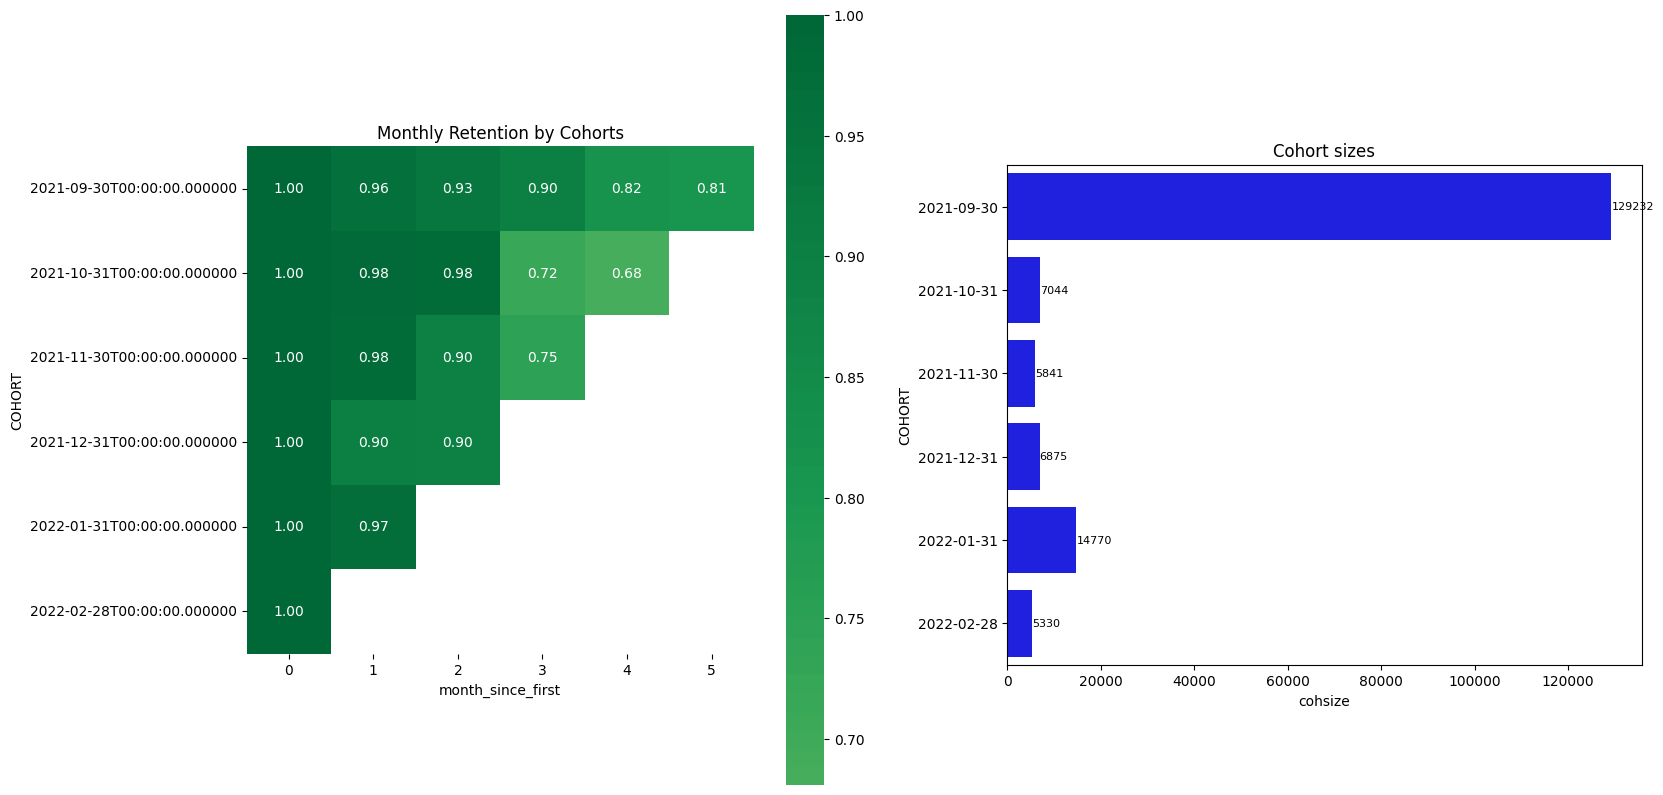

In [15]:
fig = plt.figure(figsize=(18, 10))

# Heatmap (retention)
ax1 = plt.subplot(1, 2, 1)
sns.heatmap(
    retention.round(3),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0, 
    square=True, 
    ax=ax1)
ax1.set_title('Monthly Retention by Cohorts', fontsize=12)

# bars - cohort sizes
ax2 = plt.subplot(1, 2, 2)

sns.barplot(
    x="cohsize", 
    y="COHORT", 
    data=df_cohorts_agg,
    color='blue'
    )
ax2.bar_label(ax2.containers[0], fontsize=8);
ax2.set_title('Cohort sizes', fontsize=12)
chartBox = ax2.get_position()
ax2.set_position(
    [chartBox.x0,
    chartBox.y0 + 0.12,
    chartBox.width,
    0.5]
)

#plt.tight_layout()
plt.show()

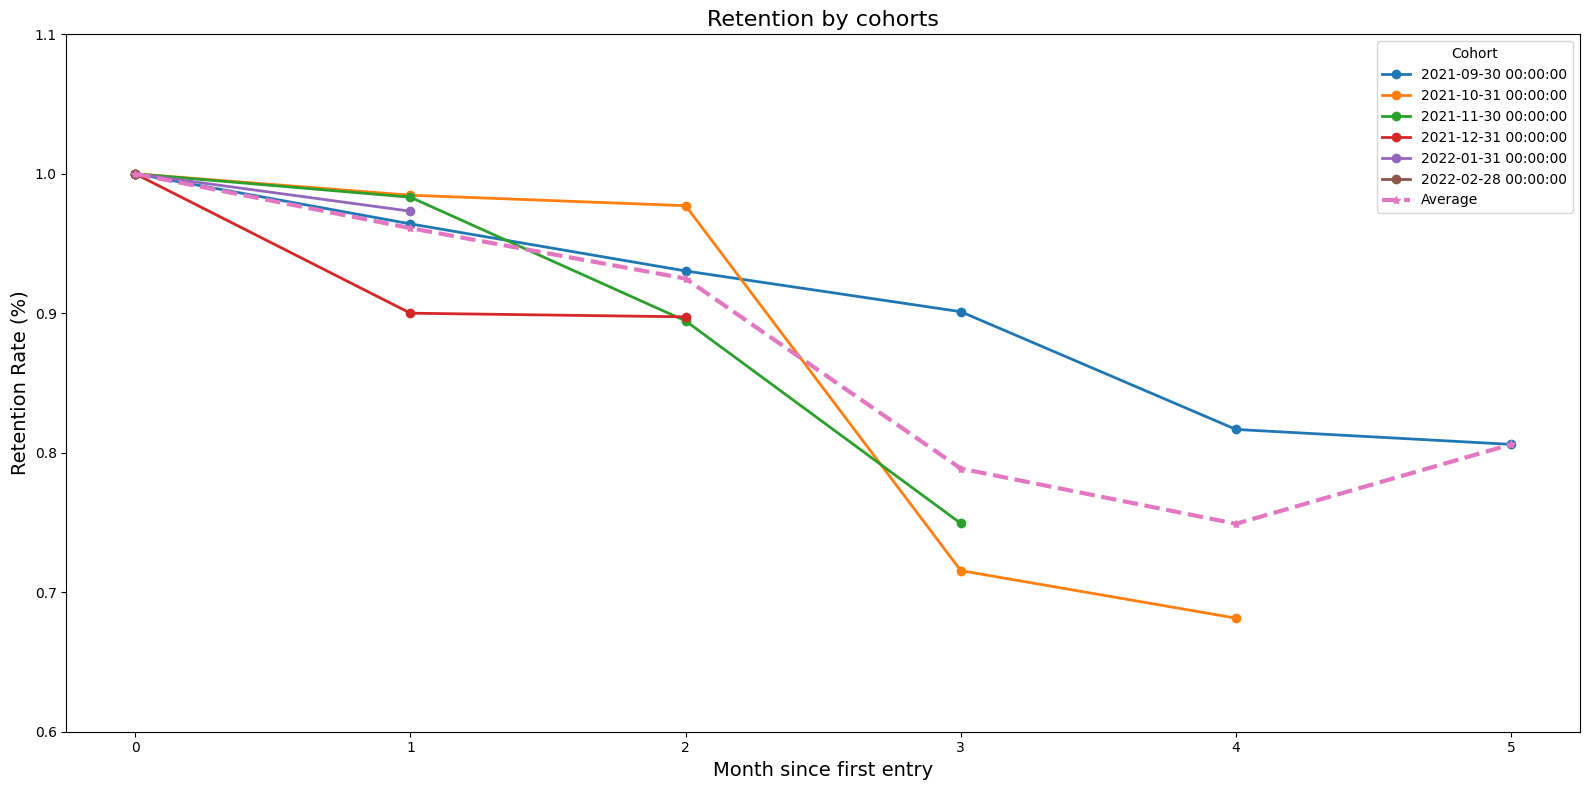

In [ ]:
# mean for line
retention_mean = retention.mean(axis=0)

# graf
plt.figure(figsize=(16, 8))

plt.plot(
    retention.T, 
    marker='o', 
    linewidth=2
)

plt.plot(
    retention_mean, 
    marker='*', 
    linewidth=3, 
    linestyle='--', 
    label='Average')

# labels + axis names
plt.title('Retention by cohorts', fontsize=16)
plt.xlabel('Month since first entry', fontsize=14)
plt.ylabel('Retention Rate (%)', fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0.6, 1.1)  # Ограничиваем ось Y до 110% для лучшей видимости

# Настройка легенды
plt.legend(
    [*retention.index, 'Average'],  # Используем индексы как названия когорт
    title='Cohort',
    loc='upper right',
    fontsize=10
)


plt.tight_layout()
plt.show()


# Выводы и рекомендации

## Общие наблюдения

1. размер первой когорты слишком велик - гипотезы описаны выше
2. наблюдается постоянное снижение удержания клиентов.
3. когорты января-февраля - не имеют смысла в наблюдениях - пока не вызрели для установки тенденции когорты

## Гипотезы к проверке

#### 1. **Гипотеза**: Новые пользователи испытываюттрудности при взаимодействии с приложением. 
(падение удержания когорты окт по сравнению с сен + ухудшение показателя в 1 мес по остальным когортам)

- Проверка: Проведение A/B тестирования изменений интерфейса или UX-решений для новых пользователей.
- Инструменты: Использование тепловых карт, сессионных записей (session replay), глубинные интервью с пользователями.

#### 2. **Гипотеза**: Проблемы технического характера негативно влияют на опыт пользователей.
(ускорение оттока во всех когортах в январе)
- Проверка: Мониторинг ошибок и сбоев в работе приложения, корреляция количества ошибок с показателями оттока пользователей.
- Инструменты: Системы мониторинга производительности приложений (APM), сбор обратной связи от пользователей.

#### 3. **Гипотеза**: Недостаточная коммуникация с пользователями снижает их лояльность.
(общая стабильная снижающаяся динамика удержания + ухудшение показателя в 1 мес по остальным когортам)
- Проверка: Оценка эффективности email-, push-уведомлений и других каналов коммуникации.
- Инструменты: Тестирование различных типов уведомлений и сообщений, измерение отклика на них.

#### 4. **Гипотеза**: У клиента нет причины вовращаться в приложение часто.
- Проверка: анализ CJM + добавление расчета глубины просмотра и длительность сессий,  CR в целевые действия
- Инструменты: RFM сегментация и построение А/Б тестов - опросов (фокус группы или количественники) вокруг этих сегментов

 
## что можно попробовать?

#### 1. **Оптимизация onboarding-процесса**
- Создание интуитивно понятного и привлекательного процесса знакомства с приложением.
- Интерактивные обчалки и подсказки для новых пользователей, геймификация по освоению функций и экранов прилодения

#### 2. **Регулярное обновление продукта**
- Добавление новых функций и возможностей. Маркетинг на пользователя о "значимых" фичах.
- Улучшение существующего функционала на основе отзывов пользователей.

#### 3. **Повышение качества технической поддержки**
- Быстрое реагирование на возникающие проблемы.
- Регулярный мониторинг стабильности и скорости работы приложения.

#### 4. **Активная коммуникация с пользователями**
- Персонализированные уведомления и письма. Система уведомлений и напоминаний.
- Программы лояльности и бонусные системы.

#### 5. **Сбор и анализ обратной связи**
- Регулярные опросы и фокус-группы.
- Открытые каналы для сбора предложений и жалоб.